In [1]:
import datetime
from functools import partial


import numpy as np

import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.optim as optim
import snntorch as snn
from snntorch import spikegen
from snntorch import surrogate
import snntorch.functional as SF

from moabb.datasets import BNCI2014_001, Gao2026

from tqdm import tqdm

# Import custom tools
from tools import get_raw_data, create_dataloaders
from tools.preprocessing import apply_mne_ica
from tools import visualize_snn_activity
from tools.training import Trainer

In [ ]:
class ChannelMinMaxNorm(nn.Module):
    """
    Applies Min-Max normalization per channel, scaling values to [0, 1].
    Serves as a strong baseline normalization technique for Rate Encoding probabilities.
    """

    def forward(self, x):
        # x shape: [Batch, Channels, H, W]
        # Normalize across spatial/temporal dimensions for each channel individually
        x_min = x.amin(dim=(2, 3), keepdim=True)
        x_max = x.amax(dim=(2, 3), keepdim=True)
        return (x - x_min) / (x_max - x_min + 1e-8)


class BCI_SNN(nn.Module):
    def __init__(self, n_classes: int, electrode_channels: int, kernel_length: int = 64, f1: int = 8, f2: int = 16, beta: float = 0.5, hidden_features: int = 128, num_steps: int = 20):
        super().__init__()
        self.n_classes = n_classes
        self.num_steps = num_steps

        # Block 1 & 2: Feature extraction (ANN part)
        # We use standard layers here to extract robust spatial-temporal features first,
        # which helps in performance on noisy BCI data.
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, f1, (1, kernel_length), padding="same", bias=False),
            nn.BatchNorm2d(f1),
            nn.ELU(),
            nn.Conv2d(f1, f2, (electrode_channels, 1), groups=f1, bias=False),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),

            nn.Conv2d(f2, f2, (1, 16), padding="same", groups=f2, bias=False),
            nn.Conv2d(f2, f2, (1, 1), bias=False),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(0.5)
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 8))

        # Block 3: Classifier (SNN part)
        self.fc1 = nn.Linear(f2 * 8, hidden_features, bias=False)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())

        self.fc2 = nn.Linear(hidden_features, n_classes, bias=False)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())

    def forward(self, x):
        # Extract features
        x = self.feature_extractor(x)
        x = self.adaptive_pool(x)

        x = x.view(x.size(0), -1)  # Flatten

        # Initialize hidden states for SNN
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []
        mem2_rec = []

        # Time loop for SNN processing the newly created spikes over time
        for step in range(self.num_steps):

            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

In [2]:
# 1. Pipeline Configuration
dataset = BNCI2014_001()

# Setting up standard industry parameters for testing a baseline
hyperparams = {
    "dataset": type(dataset).__name__,
    "split_mode": "random",
    "test_subject_id": 1,
    "batch_size": 32,
    "sample_frequency": 128,
    "learning_rate": 5e-4,
    "epochs": 300,
    "patience": 50,
    "dropout_rate": 0.5,
    "kernel_length": 64,
    "f1": 8,
    "d": 2,
    "f2": 16,
    "preprocessing": "ICA",
    "hidden_features": 32
}

# Add dynamic timestamp string to organize logs
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = f"models/eegnet/results/baseline_{hyperparams['dataset']}_{hyperparams['split_mode']}_{timestamp}"

In [3]:
X, y, metadata = get_raw_data(
    dataset, n_subjects=-1, sample_frequency=hyperparams["sample_frequency"])

# Extract dynamic dimensions from the dataset that the model needs
hyperparams["n_classes"] = metadata["n_classes"]
hyperparams["electrode_channels"] = metadata["electrode_channels"]
hyperparams["sample_length"] = metadata["sample_length"]


X, y, metadata = apply_mne_ica(
    X, y, metadata, sfreq=hyperparams["sample_frequency"], n_components=15)

Choosing from all possible events


Applying MNE ICA (method=fastica, n_components=15) to epoched data...
Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 59.7s.
Applying ICA to Epochs instance
    Transforming to ICA space (15 components)
    Zeroing out 0 ICA components
    Projecting back using 22 PCA components


In [4]:
train_loader, test_loader, metadata = create_dataloaders(
    X, y, metadata, split_mode=hyperparams["split_mode"], test_subject_id=hyperparams["test_subject_id"], batch_size=hyperparams["batch_size"])

# Extract dynamic dimensions from the dataset that the model needs
hyperparams["n_classes"] = metadata["n_classes"]
hyperparams["electrode_channels"] = metadata["electrode_channels"]
hyperparams["sample_length"] = metadata["sample_length"]

print(
    f"Data ready. Found {hyperparams['n_classes']} classes across {hyperparams['electrode_channels']} channels.")



Split Mode: RANDOM | Users pooled | test_size=0.2 | random_state=42
Training on 4148 trials from all selected subjects
Testing on 1036 trials from all selected subjects
Input Shape for Model: torch.Size([32, 1, 22, 513])
Batch size: 32 | Nº Channels: 22 | Sample length: 513
Data ready. Found 4 classes across 22 channels.


In [240]:
# 3. Model Initialization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = BCI_SNN(
    n_classes=hyperparams["n_classes"],
    electrode_channels=hyperparams["electrode_channels"],
    kernel_length=hyperparams["kernel_length"],
    f1=hyperparams["f1"],
    f2=hyperparams["f2"],
    beta=0.5
).to(device)

criterion = SF.ce_rate_loss()
optimizer = optim.Adam(model.parameters(), lr=hyperparams["learning_rate"])

Using device: cuda


In [241]:
sample_data, _ = next(iter(train_loader))
sample_data = sample_data.to(device)
print(f"Sample data shape: {sample_data.shape}")

model.forward(sample_data)[0].shape

Sample data shape: torch.Size([32, 1, 22, 513])


torch.Size([20, 32, 4])

In [242]:
print(
    f"Starting training on {hyperparams['dataset']} with {hyperparams['split_mode'].upper()} split for Subject {hyperparams['test_subject_id']} and device {device}...")

for epoch in range(hyperparams["epochs"]):
    model.train()
    running_loss = 0.0
    for batch_data, batch_labels in train_loader:
        batch_data = batch_data.to(device)
        batch_labels = batch_labels.to(device)

        # Forward pass
        spk_rec, mem_rec = model(batch_data)

        # Calculate loss (SF.ce_count_loss expects spikes [time, batch, classes] and targets [batch])
        loss = criterion(spk_rec, batch_labels)

        # Optional: Add regularization to encourage sparsity
        reg_loss = 1e-4 * torch.mean(spk_rec)
        total_loss = loss + reg_loss

        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        running_loss += loss.item()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        avg_train_loss = running_loss / len(train_loader)

        model.eval()
        test_loss = 0.0
        accuracy = 0.0
        spike_count = 0

        with torch.no_grad():
            for batch_data, batch_labels in test_loader:
                batch_data = batch_data.to(device)
                batch_labels = batch_labels.to(device)

                spk_rec, mem_rec = model.forward(batch_data)

                loss = criterion(spk_rec, batch_labels)
                spike_count += spk_rec.sum().item()

                test_loss += loss.item()
                # Correct shape evaluation for sf.accuracy_rate
                accuracy += SF.accuracy_rate(spk_rec, batch_labels)

        avg_test_loss = test_loss / len(test_loader)
        avg_accuracy = accuracy / len(test_loader)
        mean_spikes_per_trial = spike_count / len(test_loader)

        print(
            f"Epoch {epoch+1}/{hyperparams['epochs']} - Train Loss: {avg_train_loss:.4f} - Test Loss: {avg_test_loss:.4f} - Test Accuracy: {avg_accuracy:.4f} - Mean Spikes/Trial: {mean_spikes_per_trial:.2f}")

Starting training on BNCI2014_001 with RANDOM split for Subject 1 and device cuda...
Epoch 1/300 - Train Loss: 1.3858 - Test Loss: 1.3822 - Test Accuracy: 0.2522 - Mean Spikes/Trial: 22.61
Epoch 10/300 - Train Loss: 1.2327 - Test Loss: 1.2205 - Test Accuracy: 0.4839 - Mean Spikes/Trial: 592.06
Epoch 20/300 - Train Loss: 1.1754 - Test Loss: 1.1743 - Test Accuracy: 0.5208 - Mean Spikes/Trial: 622.03
Epoch 30/300 - Train Loss: 1.1599 - Test Loss: 1.1562 - Test Accuracy: 0.5483 - Mean Spikes/Trial: 618.45
Epoch 40/300 - Train Loss: 1.1402 - Test Loss: 1.1535 - Test Accuracy: 0.5590 - Mean Spikes/Trial: 712.73
Epoch 50/300 - Train Loss: 1.1292 - Test Loss: 1.1385 - Test Accuracy: 0.5666 - Mean Spikes/Trial: 728.27
Epoch 60/300 - Train Loss: 1.1187 - Test Loss: 1.1420 - Test Accuracy: 0.5729 - Mean Spikes/Trial: 719.42
Epoch 70/300 - Train Loss: 1.1100 - Test Loss: 1.1282 - Test Accuracy: 0.5963 - Mean Spikes/Trial: 715.30
Epoch 80/300 - Train Loss: 1.0991 - Test Loss: 1.1187 - Test Accuracy

KeyboardInterrupt: 

In [126]:
import math
from typing import Iterable, List, Optional, Tuple

import numpy as np
import torch
from torch import nn

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from snntorch import spikeplot as snn_spikeplot
except Exception:
    snn_spikeplot = None


def visualize_snn_activity(
    spk_rec: torch.Tensor,
    mem_rec: torch.Tensor,
    sample: int = 0,
    output_neurons: Optional[Iterable[int]] = None,
    figsize: Tuple[int, int] = (14, 9),
    palette: str = "tab10",
    title: Optional[str] = None,
    show: bool = True,
) -> Tuple[plt.Figure, List[plt.Axes]]:
    """
    Visualize SNN activity (membrane potential, spikes) for a single sample.

    Args:
        spk_rec: Tensor of shape (time_steps, batch_size, num_neurons).
        mem_rec: Tensor of shape (time_steps, batch_size, num_neurons).
        sample: batch index to visualize (default 0).
        output_neurons: iterable of output neuron indices to plot for membrane/spikes.
        figsize: figure size.
        palette: matplotlib palette name for line coloring.
        title: optional figure title.
        show: whether to call `plt.show()` before returning.

    Returns:
        (fig, [ax_membrane, ax_spikes])
    """
    # Normalize shapes if batch dim is missing
    if spk_rec.dim() == 2:
        spk_rec = spk_rec.unsqueeze(1)
        mem_rec = mem_rec.unsqueeze(1)

    T = spk_rec.size(0)

    # Extract sample
    mem2_rec = mem_rec[:, sample].cpu().numpy()
    spk2_rec = spk_rec[:, sample].cpu().numpy()

    # Choose neurons to plot
    def pick_indices(arr: np.ndarray, sel: Optional[Iterable[int]], default_max: int = 10):
        n = arr.shape[1]
        if sel is None:
            k = min(default_max, n)
            if k == 0:
                return []
            return list(range(k))
        return list(sel)

    out_idx = pick_indices(mem2_rec, output_neurons)

    sns.set(style="darkgrid")
    colors = sns.color_palette(palette, max(len(out_idx), 6))

    fig, (ax_mem, ax_spk) = plt.subplots(
        2, 1, figsize=figsize, sharex=True, gridspec_kw={"height_ratios": [1, 0.8]}
    )

    times = np.arange(T)

    # Membrane potentials
    if len(out_idx) > 0:
        for i, idx in enumerate(out_idx):
            ax_mem.plot(
                times, mem2_rec[:, idx], label=f"out{idx}", color=colors[i % len(colors)])
        ax_mem.set_ylabel("Membrane potential")
        ax_mem.legend(loc="upper right", ncol=min(3, len(out_idx)))
        ax_mem.axhline(0, color="0.6", linestyle="--")
    else:
        ax_mem.text(0.5, 0.5, "No output neurons to display",
                    ha="center", va="center")

    # Spikes raster
    if spk2_rec.size > 0 and spk2_rec.ndim == 2:
        spk_plot = spk2_rec[:, out_idx] if len(out_idx) > 0 else spk2_rec
        for i in range(spk_plot.shape[1]):
            times_i = np.where(spk_plot[:, i] > 0)[0]
            ax_spk.scatter(times_i, np.ones_like(times_i) * i,
                           marker="|", s=200, color=colors[i % len(colors)])

        ax_spk.set_ylabel("Neuron")
        ax_spk.set_xlabel("Timestep")
        ax_spk.set_yticks(range(spk_plot.shape[1]))
        ax_spk.set_yticklabels([f"n{idx}" for idx in (
            out_idx if len(out_idx) > 0 else range(spk_plot.shape[1]))])
    else:
        ax_spk.text(0.5, 0.5, "No spikes recorded", ha="center", va="center")

    if title is None:
        title = "SNN activity"
    fig.suptitle(title, fontsize=16)
    fig.tight_layout()

    if show:
        plt.show()

    return fig, [ax_mem, ax_spk]

Visualizing SNN inference for sample 0
The correct output neuron that should spike the most is: Neuron 1


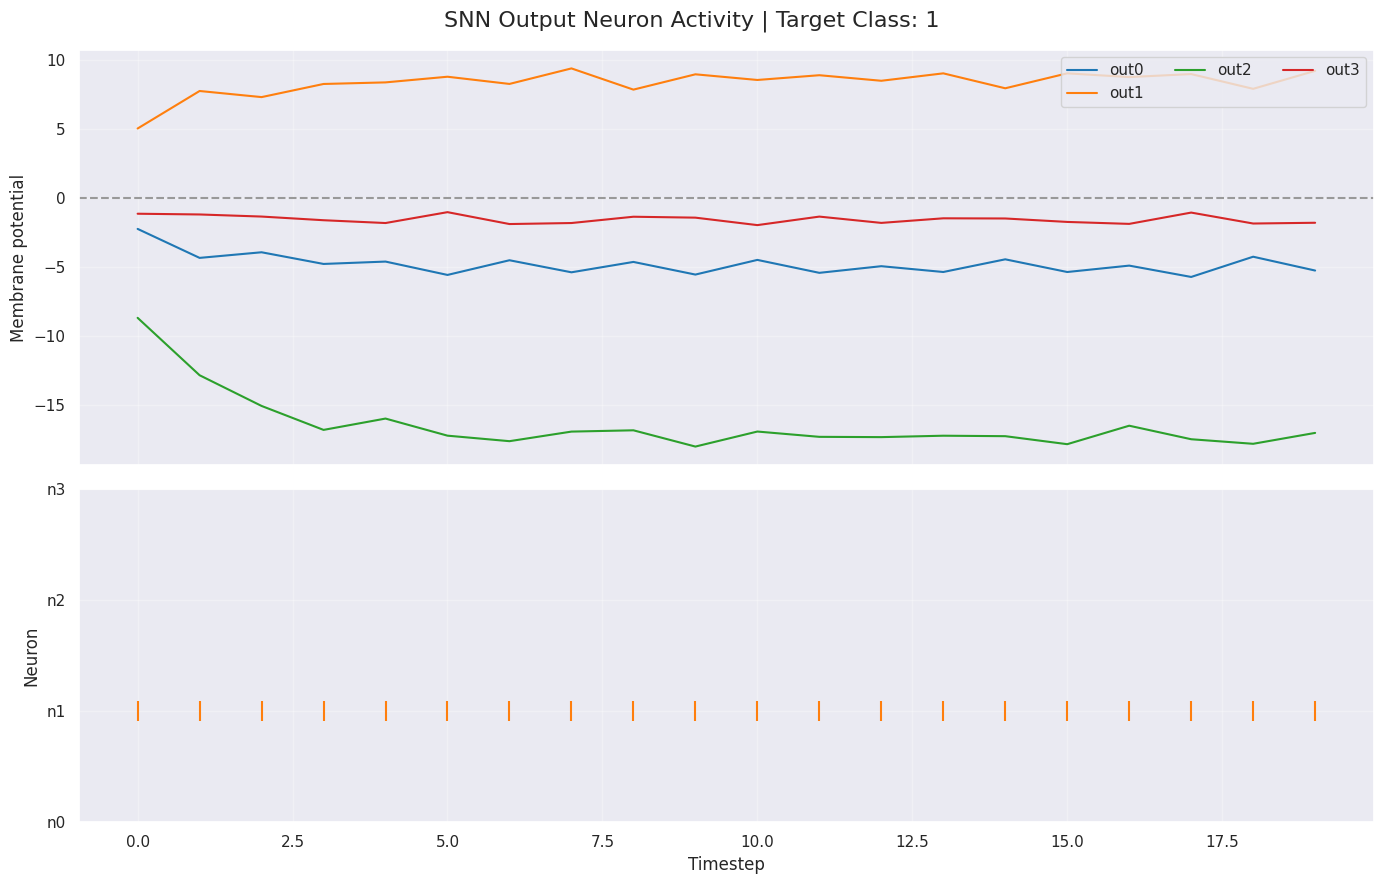

In [257]:
model.eval()

# Get a single batch from the test set
test_data, test_labels = next(iter(train_loader))
test_data = test_data.to(device)
test_labels = test_labels.to(device)

# Select a specific sample to visualize
sample_idx = 0
true_class = test_labels[sample_idx].item()

print(f"Visualizing SNN inference for sample {sample_idx}")
print(
    f"The correct output neuron that should spike the most is: Neuron {true_class}")

# Run the model to get the spikes and membrane potentials
with torch.no_grad():
    spk_rec, mem_rec = model(test_data)

# Visualize the activity
fig, ax = visualize_snn_activity(
    spk_rec=spk_rec,
    mem_rec=mem_rec,
    sample=sample_idx,
    title=f"SNN Output Neuron Activity | Target Class: {true_class}"
)